### Summary and Conclusion

This notebook brings together the key insights from the exploratory data analysis (EDA) of river water quality across South Africa and synthesizes the main spatial, distributional, and contextual patterns observed in the data. Building on the findings from the primary EDA notebooks, this section highlights overarching trends in water quality indicators, satellite-derived features, climatic variables, population density, and river system characteristics.

In addition to summarizing these patterns, this notebook focuses on examining relationships among variables through correlation analysis to identify potential associations between water quality measures and environmental or human-influenced factors. Collectively, these summaries and analyses distill the most salient findings, clarify how different drivers may interact, and support clear, data-driven conclusions within the project’s time constraints.

#### 1. Key Findings by Variable from EDA

##### a) Water Quality Indicators

Dissolved Reactive Phosphorus (DRP) exhibits a highly right-skewed distribution: most observations fall within generally acceptable ranges, while a small number of sites show substantially elevated concentrations. These high-DRP observations tend to cluster spatially rather than appearing randomly, suggesting localized nutrient enrichment driven by site-specific conditions such as downstream accumulation, urban activity, or agricultural runoff. River mouth and junction locations represent only a small fraction of sampling sites and unique geographic locations, indicating that while downstream effects are important, they are likely localized rather than dominant drivers of overall water quality variation in the dataset.

##### b) Satellite-Derived Spectral Features

Satellite-derived wavelength features (NIR, green, SWIR22) show unimodal but skewed distributions, with strong correlations among infrared bands—particularly between SWIR16 and SWIR22—indicating redundancy. Normalized indices (NDMI and MNDWI) behave differently, carrying complementary information related to vegetation moisture and surface water clarity. Spatially, higher NIR values tend to align with coastal and more urbanized regions, while NDMI patterns suggest higher moisture and vegetation presence in wetter coastal areas compared to the interior. These findings highlight both the usefulness and the multicollinearity risks of spectral features for downstream modeling.

##### c) Population Density

Population density exhibits extremely high variability across sampling locations, with the majority of sites situated in sparsely populated or rural areas and a small subset located in dense urban regions. These urban sites disproportionately influence the upper tail of the distribution, even after applying a log transformation. Spatially, higher population density values align with known urban centers, providing confidence in the population density integration. Overall, population density appears to function more as a contextual modifier—shaping local environmental pressures—rather than as a direct linear driver of water quality or spectral signals.

##### d) Climatic Variables

Potential Evapotranspiration (PET) shows clear geographic gradients across provinces, reflecting regional climatic differences within South Africa. PET exhibits a negative relationship with longitude and varies systematically across space, underscoring the strong role of climate in shaping environmental conditions. These climatic variables provide important background context for interpreting observed patterns in both water quality measurements and satellite-derived spectral features.

##### e) River Mouth and Junction Proximity

River mouth and junction indicators represent a small fraction of both total observations and unique geographic locations in the dataset. Spatial analysis shows that these sites are primarily concentrated near coastal and downstream endpoints, aligning with geographic expectations. While some elevated nutrient concentrations—particularly DRP—appear near these locations, their limited spatial coverage suggests that river mouth and junction effects are localized rather than dominant drivers of overall water quality variation. As a result, these indicators are best interpreted as contextual spatial features that may amplify local downstream effects rather than as primary explanatory variables at the national scale.

#### 2. Correlation Analysis

##### a) Library Imports

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import Normalize
from scipy.stats import pointbiserialr

##### b) Pulling the merged dataset

In [17]:
water_quality_df = pd.read_csv('data/wq.csv')
water_quality_df.head()

,province,country,latitude,longitude,sample date,nir,green,swir16,swir22,ndmi,...,total alkalinity,electrical conductance,dissolved reactive phosphorus,month,sample_year,pop_density_nn,distance_km_to_pd_cell,river_mouthORjunction,river_mouth,river_junction
0,Mpumalanga,South Africa,-26.861111,28.884722,2011-01-03,17658.5,9550.0,13746.5,10574.0,0.124566,...,74.720,162.9,163.0,2011-01-31,2011,5.049022,0.251555,0,0,0
1,Gauteng,South Africa,-26.450000,28.085833,2011-01-03,15210.0,10720.0,17974.0,14201.0,-0.083293,...,89.254,573.0,80.0,2011-01-31,2011,23.239988,0.419537,0,0,0
2,Free State,South Africa,-27.671111,27.236944,2011-01-03,14887.0,10943.0,13522.0,11403.0,0.048048,...,82.000,203.6,101.0,2011-01-31,2011,687.465759,0.069958,0,0,0
3,Free State,South Africa,-27.356667,27.286389,2011-01-03,16828.5,9502.5,12665.5,9643.0,0.141147,...,56.100,145.1,151.0,2011-01-31,2011,6.092811,0.232396,0,0,0
4,Free State,South Africa,-27.010111,26.698083,2011-01-04,12433.5,10433.5,9579.5,8531.5,0.129651,...,82.200,289.8,192.0,2011-01-31,2011,77.849716,0.466183,0,0,0


##### c) Defining and Labeling Water Quality Indicators

Why do we need this?

To support downstream correlation and comparative analyses, we convert continuous water quality measurements into simple, interpretable binary indicators (coded as 1 = acceptable and 0 = not acceptable) based on commonly cited threshold values. This allows us to summarize overall water quality status at each sampling location and to examine how environmental, climatic, and human-context variables relate to “good” versus “not acceptable” water quality conditions.

	• drp_ok: Indicates whether Dissolved Reactive Phosphorus (DRP) is within the acceptable range
              (1 = DRP ≤ 100 µg/L, 0 = DRP > 100 µg/L).

	• ta_ok: Indicates whether Total Alkalinity (TA) falls within the acceptable range
              (1 = 20–200 mg/L, 0 = outside this range).

	• ec_ok: Indicates whether Electrical Conductance (EC) is within acceptable limits
              (1 = EC ≤ 700 µS/cm, 0 = EC > 700 µS/cm).

	• good_water_quality: Indicates overall water quality status at a sampling location
              (1 = all three conditions above are met; 0 = at least one condition fails).

In [18]:
# --- Define acceptable water quality thresholds ---
DRP_MAX = 100              # µg/L
TA_MIN, TA_MAX = 20, 200   # mg/L
EC_MAX = 700               # µS/cm

water_quality_labeled_df = water_quality_df.copy()

# Ensure numeric columns
cols_numeric = [
    "dissolved reactive phosphorus",
    "total alkalinity",
    "electrical conductance"
]
water_quality_labeled_df[cols_numeric] = (
    water_quality_labeled_df[cols_numeric]
    .apply(pd.to_numeric, errors="coerce")
)

# Individual binary flags (1 = acceptable, 0 = not acceptable)
water_quality_labeled_df["drp_ok"] = (
    water_quality_labeled_df["dissolved reactive phosphorus"] <= DRP_MAX
).astype(int)

water_quality_labeled_df["ta_ok"] = (
    water_quality_labeled_df["total alkalinity"].between(TA_MIN, TA_MAX)
).astype(int)

water_quality_labeled_df["ec_ok"] = (
    water_quality_labeled_df["electrical conductance"] <= EC_MAX
).astype(int)

# Overall water quality label
water_quality_labeled_df["good_water_quality"] = (
    (water_quality_labeled_df["drp_ok"] == 1) &
    (water_quality_labeled_df["ta_ok"] == 1) &
    (water_quality_labeled_df["ec_ok"] == 1)
).astype(int)

# Preview
water_quality_labeled_df.head()

,province,country,latitude,longitude,sample date,nir,green,swir16,swir22,ndmi,...,sample_year,pop_density_nn,distance_km_to_pd_cell,river_mouthORjunction,river_mouth,river_junction,drp_ok,ta_ok,ec_ok,good_water_quality
0,Mpumalanga,South Africa,-26.861111,28.884722,2011-01-03,17658.5,9550.0,13746.5,10574.0,0.124566,...,2011,5.049022,0.251555,0,0,0,0,1,1,0
1,Gauteng,South Africa,-26.450000,28.085833,2011-01-03,15210.0,10720.0,17974.0,14201.0,-0.083293,...,2011,23.239988,0.419537,0,0,0,1,1,1,1
2,Free State,South Africa,-27.671111,27.236944,2011-01-03,14887.0,10943.0,13522.0,11403.0,0.048048,...,2011,687.465759,0.069958,0,0,0,0,1,1,0
3,Free State,South Africa,-27.356667,27.286389,2011-01-03,16828.5,9502.5,12665.5,9643.0,0.141147,...,2011,6.092811,0.232396,0,0,0,0,1,1,0
4,Free State,South Africa,-27.010111,26.698083,2011-01-04,12433.5,10433.5,9579.5,8531.5,0.129651,...,2011,77.849716,0.466183,0,0,0,0,1,1,0


##### d) Counts and Proportions of Water Quality Classes

In [25]:
# List of binary water quality indicators
binary_vars = ["drp_ok", "ta_ok", "ec_ok", "good_water_quality"]

# Build summary tables for each variable
binary_summaries = {}

for var in binary_vars:
    counts = water_quality_labeled_df[var].value_counts().sort_index()
    proportions = (
        water_quality_labeled_df[var]
        .value_counts(normalize=True)
        .sort_index()
    )

    binary_summaries[var] = pd.DataFrame({
        "count": counts,
        "proportion": proportions
    })

# Display summaries
binary_summaries

{'drp_ok':         count  proportion
 drp_ok                   
 0        1459    0.160453
 1        7634    0.839547,
 'ta_ok':        count  proportion
 ta_ok                   
 0       2046    0.225008
 1       7047    0.774992,
 'ec_ok':        count  proportion
 ec_ok                   
 0       2225    0.244694
 1       6868    0.755306,
 'good_water_quality':                     count  proportion
 good_water_quality                   
 0                    4053    0.445727
 1                    5040    0.554273}

Observation: Most sampling locations meet the acceptable thresholds for individual water quality indicators, particularly Dissolved Reactive Phosphorus (≈84%), Total Alkalinity (≈77%), and Electrical Conductance (≈76%). However, when these criteria are evaluated jointly, only about 55% of observations satisfy all three thresholds simultaneously and are classified as having acceptable overall water quality. This gap highlights how moderate exceedances across different indicators compound to reduce overall water quality status. 

##### e) Correlation Overview of Water Quality and Associated Variables

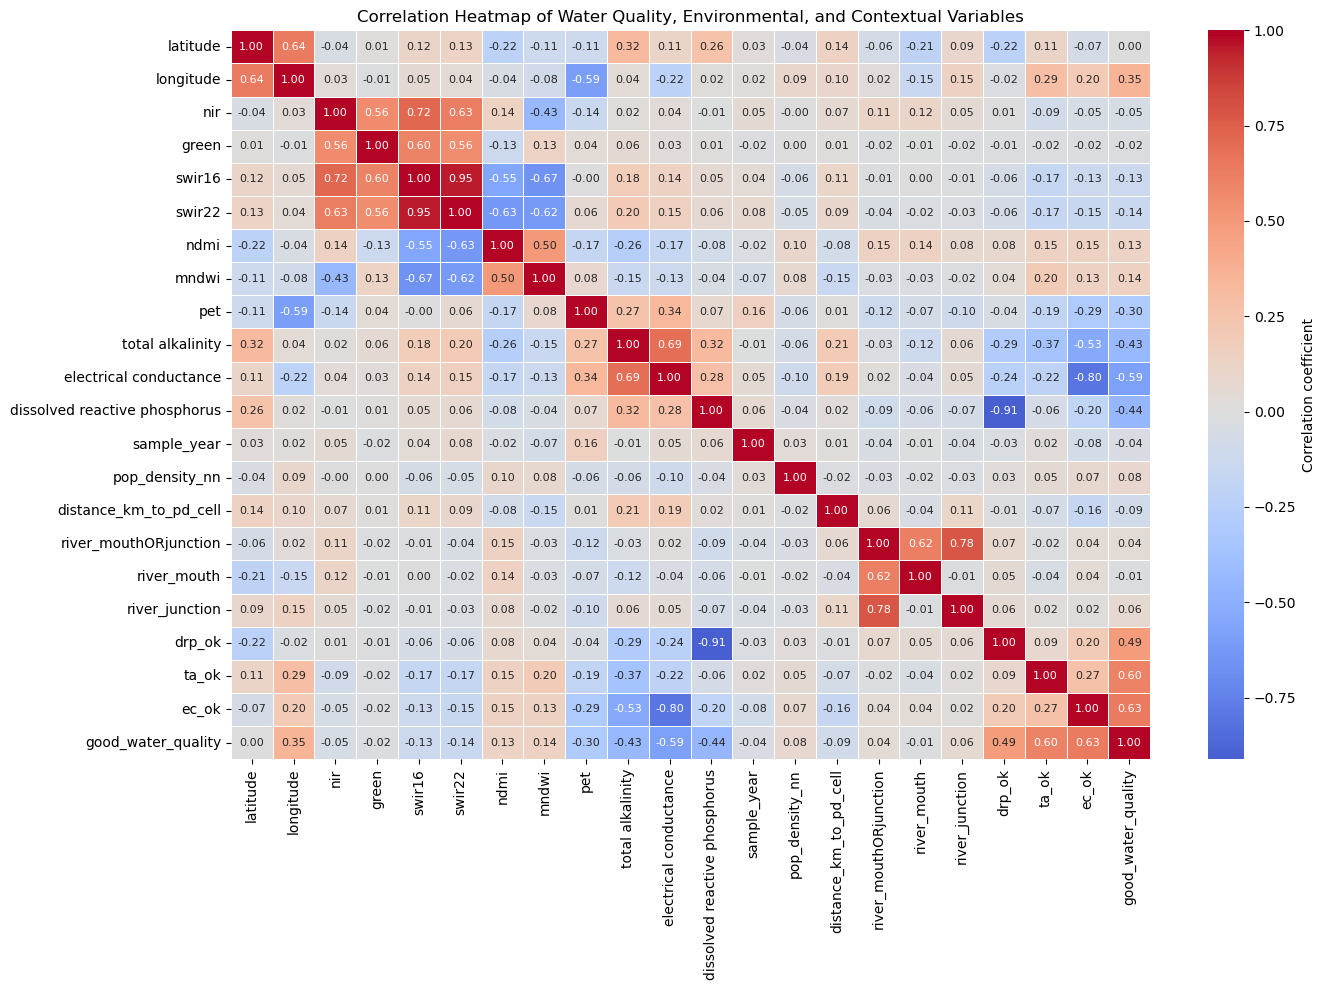

In [20]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,          # <-- show numbers
    fmt=".2f",           # <-- 2 decimal places
    annot_kws={"size": 8},
    cbar_kws={"label": "Correlation coefficient"}
)

plt.title("Correlation Heatmap of Water Quality, Environmental, and Contextual Variables")
plt.tight_layout()
plt.show()

##### f) Key Takeaways from the Correlation Analysis

•	Strong multicollinearity exists among satellite-derived spectral features, especially between SWIR16 and SWIR22, confirming redundancy among closely related infrared bands and motivating feature reduction for downstream modeling.

•	Total Alkalinity and Electrical Conductance are strongly positively correlated, suggesting they reflect related geochemical processes and may jointly characterize ionic content in river water.

•	Normalized indices (NDMI, MNDWI) exhibit weaker correlations with raw spectral bands, indicating they capture complementary information related to vegetation moisture and surface water clarity rather than simple reflectance intensity.

•	Population density and climatic variables (PET) show generally modest correlations with individual water quality measures, implying their influence is likely indirect, contextual, or mediated through local land use and hydrological processes rather than linear effects.

•	The binary indicators (drp_ok, ta_ok, ec_ok) and the composite good_water_quality label are positively correlated by construction, validating the threshold-based encoding and confirming internal consistency of the classification logic.

•	Spatial indicators (river mouth and junction flags, distance to population density cell) show limited direct correlation with most variables, suggesting downstream effects are localized rather than dominant drivers across the full dataset.



#### 2.1 Point-Biserial Correlation Analysis (Continuous vs. Binary Variables)

##### a) Why do we do this analysis?

Point-biserial correlation is used to assess associations between continuous environmental variables and binary water quality indicators (0/1), enabling consistent comparison across mixed variable types.

##### b) Compute Point-Biserial Correlations


Step 1: Select Variables

In [21]:
# Binary variables (0/1)
binary_vars = [
    "good_water_quality",
    "drp_ok",
    "ta_ok",
    "ec_ok",
    "river_mouthORjunction"
]

# Continuous variables
continuous_vars = [
    "dissolved reactive phosphorus",
    "total alkalinity",
    "electrical conductance",
    "nir",
    "green",
    "swir16",
    "swir22",
    "ndmi",
    "mndwi",
    "pet",
    "pop_density_nn"
]

Step 2: Compute point-biserial correlations

In [22]:
results = []

for b in binary_vars:
    for c in continuous_vars:
        df_pair = water_quality_labeled_df[[b, c]].dropna()
        
        if df_pair[b].nunique() == 2:
            r, p = pointbiserialr(df_pair[b], df_pair[c])
            results.append({
                "binary_variable": b,
                "continuous_variable": c,
                "correlation": r,
                "p_value": p
            })

In [23]:
pb_corr_df = pd.DataFrame(results)
pb_corr_df.sort_values("correlation", key=abs, ascending=False).head(10)


,binary_variable,continuous_variable,correlation,p_value
11,drp_ok,dissolved reactive phosphorus,-0.911589,0.000000e+00
35,ec_ok,electrical conductance,-0.803375,0.000000e+00
2,good_water_quality,electrical conductance,-0.588574,0.000000e+00
34,ec_ok,total alkalinity,-0.533938,0.000000e+00
0,good_water_quality,dissolved reactive phosphorus,-0.444231,0.000000e+00
1,good_water_quality,total alkalinity,-0.428389,0.000000e+00
23,ta_ok,total alkalinity,-0.365289,4.289792e-285
9,good_water_quality,pet,-0.297421,4.082309e-185
42,ec_ok,pet,-0.294826,8.726617e-182
12,drp_ok,total alkalinity,-0.291083,4.797452e-177


Step 3: Pivot for heatmap-style table

In [24]:
pb_corr_matrix = pb_corr_df.pivot(
    index="continuous_variable",
    columns="binary_variable",
    values="correlation"
)

pb_corr_matrix

binary_variable,drp_ok,ec_ok,good_water_quality,river_mouthORjunction,ta_ok
continuous_variable,,,,,
dissolved reactive phosphorus,-0.911589,-0.201899,-0.444231,-0.091098,-0.064541
electrical conductance,-0.244383,-0.803375,-0.588574,0.015284,-0.215568
green,-0.013082,-0.022798,-0.018654,-0.019538,-0.018311
mndwi,0.037444,0.134260,0.143267,-0.029890,0.199270
ndmi,0.077008,0.146087,0.129586,0.145730,0.146409
nir,0.005233,-0.048649,-0.051967,0.112276,-0.086981
pet,-0.042306,-0.294826,-0.297421,-0.122919,-0.191708
pop_density_nn,0.027985,0.072476,0.084844,-0.034674,0.051015
swir16,-0.055126,-0.133395,-0.131841,-0.010601,-0.169974


##### c) Analysis

The point-biserial correlation analysis shows that the binary water quality indicators are most closely related to the chemical measurements used to define them. Dissolved Reactive Phosphorus (DRP) has a very strong negative correlation with the drp_ok indicator, and Electrical Conductance is strongly negatively correlated with ec_ok, which is expected and confirms that the threshold-based classification is working as intended. Overall water quality (good_water_quality) is most strongly associated with the core chemistry variables—especially Electrical Conductance, Total Alkalinity, and DRP—indicating that chemical conditions are the main factors determining whether water quality is classified as acceptable or not. The weaker relationship between Total Alkalinity and ta_ok likely reflects the wide acceptable range for alkalinity, which makes the binary indicator less sensitive to changes in TA values.

In contrast, satellite-derived spectral features, normalized indices, population density, climatic variables (including PET), and river mouth or junction indicators show weak direct correlations with binary water quality outcomes. This suggests that these variables affect water quality indirectly, by influencing the underlying chemical conditions rather than directly crossing regulatory thresholds. Importantly, these results also depend on how acceptable ranges are defined: broader or more flexible thresholds naturally reduce the strength of binary correlations. Overall, many of these contextual variables help explain spatial and environmental variation in water quality, but they are not dominant drivers on their own across all sampling locations.0

#### Conclusion and Recommentations

This analysis combined water quality measurements with satellite-derived spectral features, climatic variables, population density, and spatial indicators to examine patterns in river water quality across South Africa. Overall, the observed distributions and spatial patterns are coherent and geographically consistent, providing confidence in the preprocessing steps, spatial joins, and feature construction applied throughout the project.

Core chemical variables—particularly Dissolved Reactive Phosphorus, Electrical Conductance, and Total Alkalinity—emerge as the primary determinants of whether a sampling location meets acceptable water quality thresholds. Binary indicators derived from these measures show strong alignment with their underlying continuous values, supporting the use of threshold-based classifications to summarize overall water quality status. In contrast, population density, climate, satellite spectral features, and river mouth or junction indicators exhibit weaker direct associations, suggesting they influence water quality indirectly by shaping underlying chemical conditions rather than acting as dominant standalone drivers.

Taken together, these findings highlight the value of integrating direct water chemistry measurements with environmental and spatial context. For future analysis, chemical indicators should remain the primary response variables, while contextual features such as climate, population density, and spectral indices can be used to explain variability, identify risk factors, and support predictive modeling. This integrated approach provides a strong foundation for downstream modeling, scenario analysis, and more targeted water quality monitoring and management efforts within the study region.

Next Steps...

Based on the exploratory and correlation analyses, several directions emerge for strengthening both interpretation and downstream modeling of river water quality:

1.	Prioritize chemical indicators in modeling efforts

Dissolved Reactive Phosphorus (DRP), Electrical Conductance (EC), and Total Alkalinity (TA) show the strongest and most direct relationships with overall water quality status. Future predictive or classification models should treat these variables as core inputs, with other features playing a supporting role.

2.	Use contextual variables as modifiers rather than primary drivers

Population density, climatic variables (e.g., PET), satellite-derived spectral features, and river mouth or junction indicators exhibit weaker direct associations with binary water quality outcomes. These variables are better suited for explaining spatial variability, identifying localized risk factors, or enhancing model interpretability rather than serving as standalone predictors.

3.	Refine threshold-based classifications where appropriate

The weaker association between Total Alkalinity and its binary indicator suggests that broad acceptable ranges can mask meaningful variation. Sensitivity analyses using alternative thresholds or multi-level classifications (e.g., low / moderate / high risk) may improve interpretability and robustness.

4.	Explore interaction and regional effects

Future analyses should examine whether relationships between contextual variables and water quality differ by region, climate zone, or proximity to urban centers. Interaction terms or stratified analyses may uncover localized drivers that are not apparent in global correlations.

5.	Incorporate temporal dynamics

Extending the analysis to explicitly model seasonal or year-to-year variation could provide additional insight into how climate variability and human activity influence water quality over time.